Total classes: 3
Total images: 7493
Max class: HCC 2710
Min class: Normal 2114


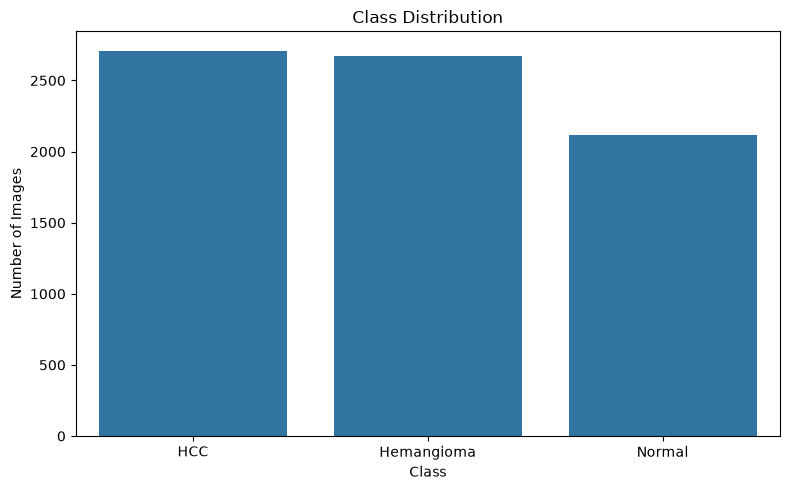

Imbalance Ratio: 1.28


In [34]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

DATA_DIR = os.path.abspath("data")  # workspace-relative 'data' folder
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR not found at {DATA_DIR}. Create a 'data' folder with class subfolders (e.g. Normal/, HCC/, Hemangioma/).")

plots_dir = os.path.abspath("plots")
os.makedirs(plots_dir, exist_ok=True)

classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
num_classes = len(classes)

count = {}
for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    count[cls] = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])

total_imgs = sum(count.values()) if count else 0

print("Total classes:", num_classes)
print("Total images:", total_imgs)
if count:
    print("Max class:", max(count, key=count.get), count[max(count, key=count.get)])
    print("Min class:", min(count, key=count.get), count[min(count, key=count.get)])

plt.figure(figsize=(8, 5))
sns.barplot(x=list(count.keys()), y=list(count.values()))
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'class_distribution.png'))
plt.show()

if count:
    max_class = max(count.values())
    min_class = min(count.values())
    print("Imbalance Ratio:", round(max_class / min_class, 2))

In [35]:
corrupt = 0
shapes = []

for cls in classes:
    path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            corrupt += 1
        else:
            shapes.append(img.shape)

print("Corrupt images:", corrupt)
print("Unique image shapes (sample):", set(shapes[:200]))

Corrupt images: 0
Unique image shapes (sample): {(512, 512, 3)}


In [36]:
import cv2
import numpy as np

NORM_DIR = os.path.abspath("data_normalized")
TARGET_SIZE = 300  # fixed square canvas, same for every class/image

def center_crop_resize(img, target_size=TARGET_SIZE):
    """Center-crop to a square (based on the smaller dimension), then resize.
    No padding, no black borders — avoids introducing a new per-class
    aspect-ratio fingerprint."""
    h, w = img.shape[:2]
    min_dim = min(h, w)
    y_start = (h - min_dim) // 2
    x_start = (w - min_dim) // 2
    cropped = img[y_start:y_start + min_dim, x_start:x_start + min_dim]
    resized = cv2.resize(cropped, (target_size, target_size), interpolation=cv2.INTER_AREA)
    return resized

# def pad_resize(img, target_size=TARGET_SIZE):
#     """Resize preserving aspect ratio, then pad to a fixed square canvas.
#     No stretching, no per-class resolution fingerprint left behind."""
#     h, w = img.shape[:2]
#     scale = target_size / max(h, w)
#     new_w, new_h = int(w * scale), int(h * scale)
#     resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

#     canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
#     y_off = (target_size - new_h) // 2
#     x_off = (target_size - new_w) // 2
#     canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
#     return canvas

os.makedirs(NORM_DIR, exist_ok=True)

for cls in classes:
    src_dir = os.path.join(DATA_DIR, cls)
    dst_dir = os.path.join(NORM_DIR, cls)
    os.makedirs(dst_dir, exist_ok=True)

    for fname in os.listdir(src_dir):
        src_path = os.path.join(src_dir, fname)
        img = cv2.imread(src_path)
        if img is None:
            continue
        img_norm = center_crop_resize(img)

        # Force every image to the SAME format — kills the jpg/png class signal
        new_name = os.path.splitext(fname)[0] + ".png"
        cv2.imwrite(os.path.join(dst_dir, new_name), img_norm)

print("Normalization done. New source folder:", NORM_DIR)
print("Every image is now", TARGET_SIZE, "x", TARGET_SIZE, "and saved as .png")


Normalization done. New source folder: d:\Livora\data_normalized
Every image is now 300 x 300 and saved as .png


In [37]:
sample_img = cv2.imread(os.path.join(DATA_DIR, classes[0], os.listdir(os.path.join(DATA_DIR, classes[0]))[0]))
print("Are R/G/B channels identical?", np.array_equal(sample_img[:,:,0], sample_img[:,:,1]))

Are R/G/B channels identical? True


In [38]:
import shutil
from sklearn.model_selection import train_test_split

SPLIT_DIR = os.path.abspath("data_split")
os.makedirs(SPLIT_DIR, exist_ok=True)
SPLITS = ["train", "val", "test"]
RATIOS = [0.7, 0.15, 0.15]

for split in SPLITS:
    for cls in classes:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in classes:
    cls_path = os.path.join(NORM_DIR, cls)
    images = os.listdir(cls_path)

    train_imgs, temp_imgs = train_test_split(images, test_size=(RATIOS[1]+RATIOS[2]), random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=RATIOS[2]/(RATIOS[1]+RATIOS[2]), random_state=42)

    for img_set, split_name in [(train_imgs, "train"), (val_imgs, "val"), (test_imgs, "test")]:
        for img_name in img_set:
            shutil.copy(
                os.path.join(cls_path, img_name),
                os.path.join(SPLIT_DIR, split_name, cls, img_name)
            )

for split in SPLITS:
    print(f"\n{split.upper()}:")
    for cls in classes:
        n = len(os.listdir(os.path.join(SPLIT_DIR, split, cls)))
        print(f"  {cls}: {n}")


TRAIN:
  HCC: 1897
  Hemangioma: 1868
  Normal: 1479

VAL:
  HCC: 406
  Hemangioma: 400
  Normal: 317

TEST:
  HCC: 407
  Hemangioma: 401
  Normal: 318


In [39]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
)

val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
val_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'), target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

# Class imbalance handling — computed from actual train counts, not guessed
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Model: frozen MobileNetV2 base + custom head
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze for initial training — prevents overfitting on small data

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)  # overfitting guard
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True)
]

# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=30,
#     class_weight=class_weight_dict,
#     callbacks=callbacks
# )

Found 5244 images belonging to 3 classes.
Found 1123 images belonging to 3 classes.
Found 1126 images belonging to 3 classes.
Class weights: {0: np.float64(0.9214549288350027), 1: np.float64(0.9357601713062098), 2: np.float64(1.1818796484110885)}


In [41]:
base_model.trainable = True
for layer in base_model.layers[:-30]:  # unfreeze only last 30 layers
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
history_fine = model.fit(train_gen, validation_data=val_gen, epochs=15, class_weight=class_weight_dict, callbacks=callbacks)

Epoch 1/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.8839 - loss: 0.2551

164/164 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.8783 - loss: 0.2643 - val_accuracy: 0.8531 - val_loss: 0.3461 - learning_rate: 1.0000e-05
Epoch 2/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.8949 - loss: 0.2341

164/164 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.8894 - loss: 0.2416 - val_accuracy: 0.8620 - val_loss: 0.3202 - learning_rate: 1.0000e-05
Epoch 3/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.8909 - loss: 0.2466

164/164 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8904 - loss: 0.2458 - val_accuracy: 0.8691 - val_loss: 0.2928 - learning_rate: 1.0000e-05
Epoch 4/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.8940 - loss: 0.2216

164/164 ━━━━━━━━━━━━━━━━━━━━ 136s 829ms/step - accuracy: 0.9001 - loss: 0.2187 - val_accuracy: 0.8842 - val_loss: 0.2645 - learning_rate: 1.0000e-05
Epoch 5/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.9001 - loss: 0.2195

...

164/164 ━━━━━━━━━━━━━━━━━━━━ 129s 784ms/step - accuracy: 0.9216 - loss: 0.1728 - val_accuracy: 0.9136 - val_loss: 0.2086 - learning_rate: 1.0000e-05
Epoch 11/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.9282 - loss: 0.1605

164/164 ━━━━━━━━━━━━━━━━━━━━ 129s 788ms/step - accuracy: 0.9287 - loss: 0.1618 - val_accuracy: 0.9181 - val_loss: 0.1976 - learning_rate: 1.0000e-05
Epoch 12/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 129s 784ms/step - accuracy: 0.9312 - loss: 0.1627 - val_accuracy: 0.9136 - val_loss: 0.1981 - learning_rate: 1.0000e-05
Epoch 13/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.9345 - loss: 0.1579

164/164 ━━━━━━━━━━━━━━━━━━━━ 128s 782ms/step - accuracy: 0.9346 - loss: 0.1543 - val_accuracy: 0.9163 - val_loss: 0.1795 - learning_rate: 1.0000e-05
Epoch 14/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.9358 - loss: 0.1513

164/164 ━━━━━━━━━━━━━━━━━━━━ 131s 799ms/step - accuracy: 0.9355 - loss: 0.1524 - val_accuracy: 0.9190 - val_loss: 0.1718 - learning_rate: 1.0000e-05
Epoch 15/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.9383 - loss: 0.1452

164/164 ━━━━━━━━━━━━━━━━━━━━ 129s 787ms/step - accuracy: 0.9336 - loss: 0.1493 - val_accuracy: 0.9234 - val_loss: 0.1655 - learning_rate: 1.0000e-05


In [42]:
import matplotlib.pyplot as plt

def plot_training_curves(history, history_fine=None, save_path=None):
    """
    Plots accuracy and loss curves for training/validation.
    If history_fine is given (fine-tuning phase), it's stitched on
    after `history` so you see the full training timeline.
    """
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    if history_fine is not None:
        acc += history_fine.history["accuracy"]
        val_acc += history_fine.history["val_accuracy"]
        loss += history_fine.history["loss"]
        val_loss += history_fine.history["val_loss"]
        switch_epoch = len(history.history["accuracy"])
    else:
        switch_epoch = None

    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, acc, label="Train Accuracy")
    axes[0].plot(epochs_range, val_acc, label="Val Accuracy")
    if switch_epoch:
        axes[0].axvline(switch_epoch, color="gray", linestyle="--", label="Fine-tune start")
    axes[0].set_title("Accuracy over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, loss, label="Train Loss")
    axes[1].plot(epochs_range, val_loss, label="Val Loss")
    if switch_epoch:
        axes[1].axvline(switch_epoch, color="gray", linestyle="--", label="Fine-tune start")
    axes[1].set_title("Loss over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [43]:
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

def evaluate_model(model, test_gen, class_names, save_dir=None):
    """
    Runs a full evaluation on test_gen:
      - overall test accuracy
      - per-class accuracy
      - precision / recall / f1 (per class + macro/weighted avg)
      - confusion matrix heatmap
      - ROC curve (one-vs-rest) per class with AUC

    Returns a dict with the key numbers so you can reuse them later.
    """
    test_gen.reset()
    y_true = test_gen.classes
    steps = int(np.ceil(test_gen.samples / test_gen.batch_size))

    y_pred_probs = model.predict(test_gen, steps=steps, verbose=1)
    y_pred_probs = y_pred_probs[: len(y_true)]  # trim overshoot from last batch
    y_pred = np.argmax(y_pred_probs, axis=1)

    overall_acc = accuracy_score(y_true, y_pred)
    print(f"\nOverall Test Accuracy: {overall_acc:.4f}\n")

    # ---- Classification report (precision, recall, f1, support) ----
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # ---- Per-class accuracy (recall of each class on its own images) ----
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print("Per-class accuracy:")
    for cls, a in zip(class_names, per_class_acc):
        print(f"  {cls}: {a:.4f}")

    # ---- Confusion matrix heatmap ----
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # ---- Per-class precision/recall/f1 bar chart ----
    metrics_cols = ["precision", "recall", "f1-score"]
    x = np.arange(len(class_names))
    width = 0.25
    plt.figure(figsize=(9, 5))
    for i, m in enumerate(metrics_cols):
        vals = [report_dict[c][m] for c in class_names]
        plt.bar(x + i * width, vals, width, label=m)
    plt.xticks(x + width, class_names, rotation=30, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("Precision / Recall / F1 by Class")
    plt.legend()
    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "precision_recall_f1.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # ---- ROC curves (one-vs-rest, multiclass) ----
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (One-vs-Rest)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "roc_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "overall_accuracy": overall_acc,
        "per_class_accuracy": dict(zip(class_names, per_class_acc)),
        "classification_report": report_dict,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_probs": y_pred_probs,
    }

36/36 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step

Overall Test Accuracy: 0.9290

              precision    recall  f1-score   support

         HCC       0.95      0.85      0.90       407
  Hemangioma       0.87      0.95      0.91       401
      Normal       1.00      1.00      1.00       318

    accuracy                           0.93      1126
   macro avg       0.94      0.93      0.93      1126
weighted avg       0.93      0.93      0.93      1126

Per-class accuracy:
  HCC: 0.8526
  Hemangioma: 0.9501
  Normal: 1.0000


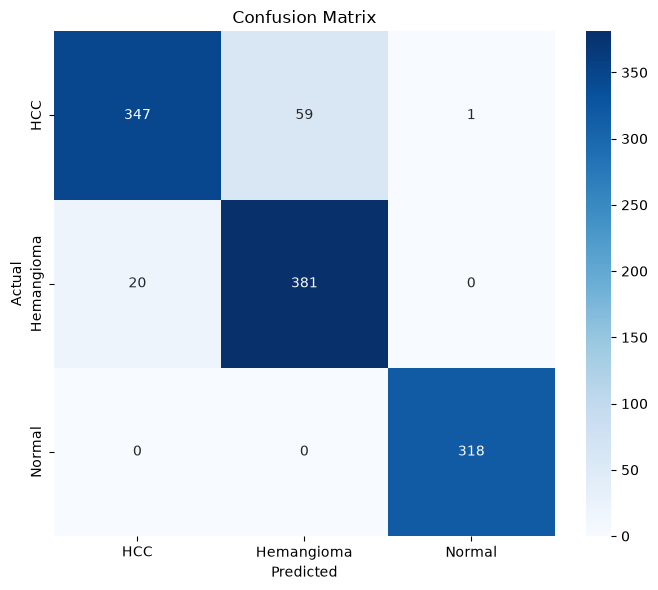

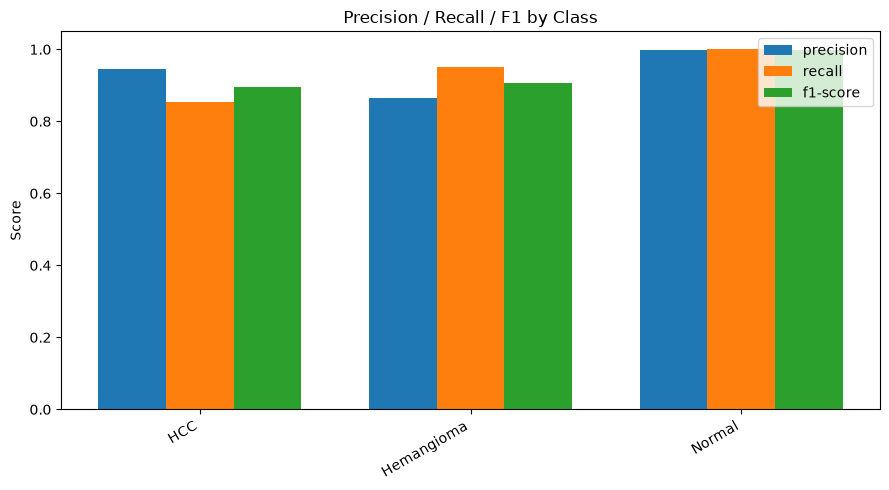

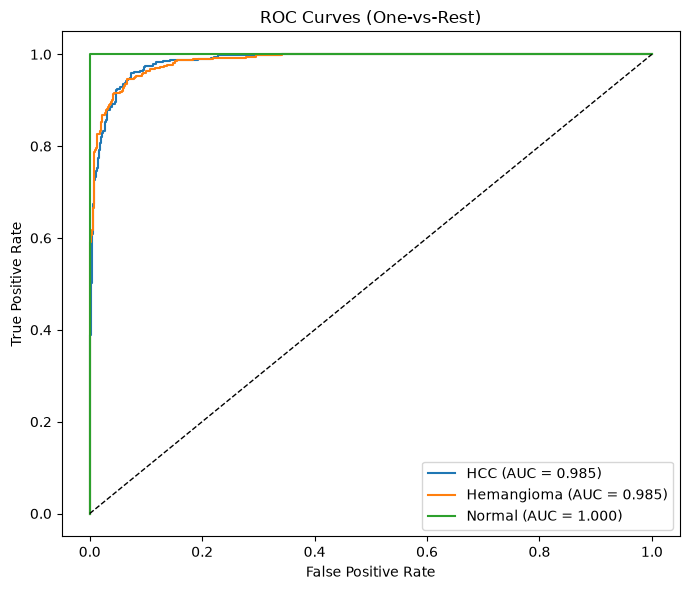

In [44]:
class_names = list(test_gen.class_indices.keys())
results = evaluate_model(model, test_gen, class_names, save_dir=plots_dir)

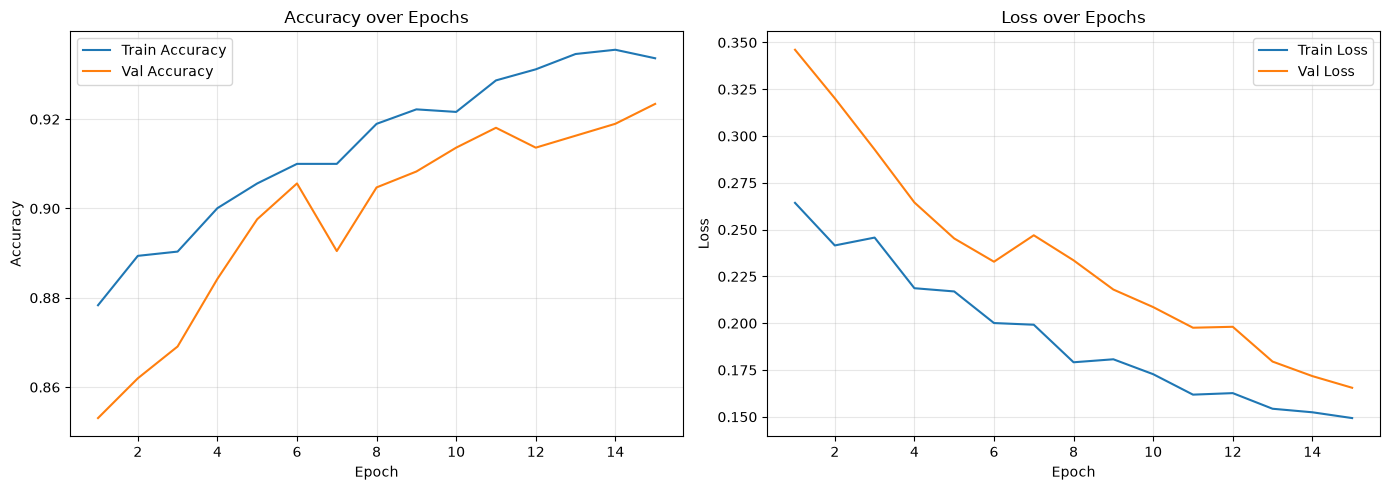

In [45]:
# You only ran history_fine, so just plot that on its own
plot_training_curves(history_fine, save_path=os.path.join(plots_dir, "training_curves.png"))

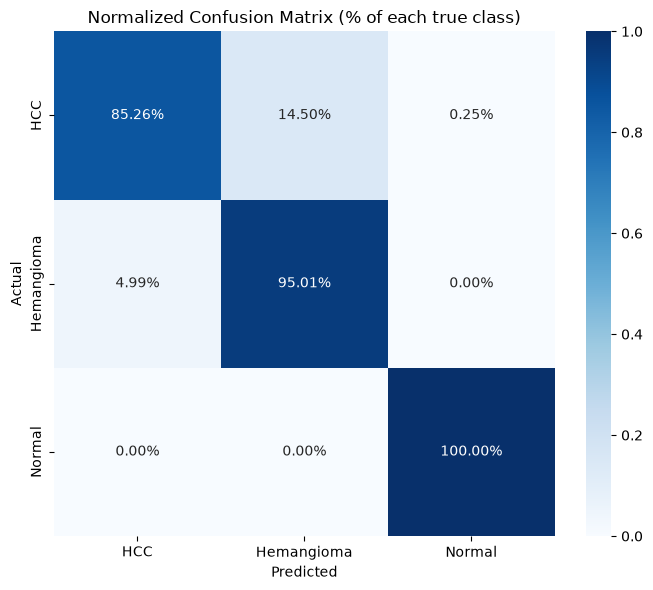

In [46]:
cm = results["confusion_matrix"]
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix (% of each true class)")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "confusion_matrix_normalized.png"), dpi=150, bbox_inches="tight")
plt.show()

In [47]:
def top_k_accuracy(y_true, y_pred_probs, k=2):
    top_k_preds = np.argsort(y_pred_probs, axis=1)[:, -k:]
    correct = [y_true[i] in top_k_preds[i] for i in range(len(y_true))]
    return np.mean(correct)

for k in [1, 2, 3]:
    if k <= len(class_names):
        acc_k = top_k_accuracy(results["y_true"], results["y_pred_probs"], k=k)
        print(f"Top-{k} Accuracy: {acc_k:.4f}")

Top-1 Accuracy: 0.9290
Top-2 Accuracy: 0.9991
Top-3 Accuracy: 1.0000


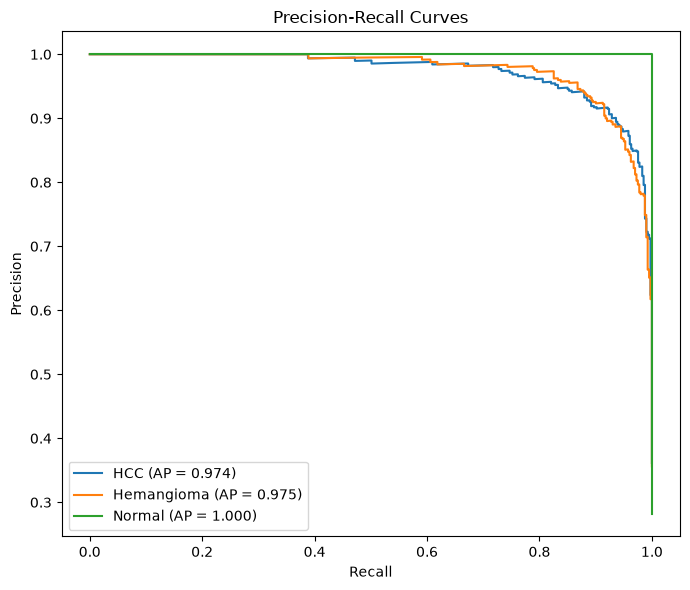

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(results["y_true"], classes=list(range(len(class_names))))

plt.figure(figsize=(7, 6))
for i, cls in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], results["y_pred_probs"][:, i])
    ap = average_precision_score(y_true_bin[:, i], results["y_pred_probs"][:, i])
    plt.plot(recall, precision, label=f"{cls} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "precision_recall_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

Total misclassified: 80 / 1126


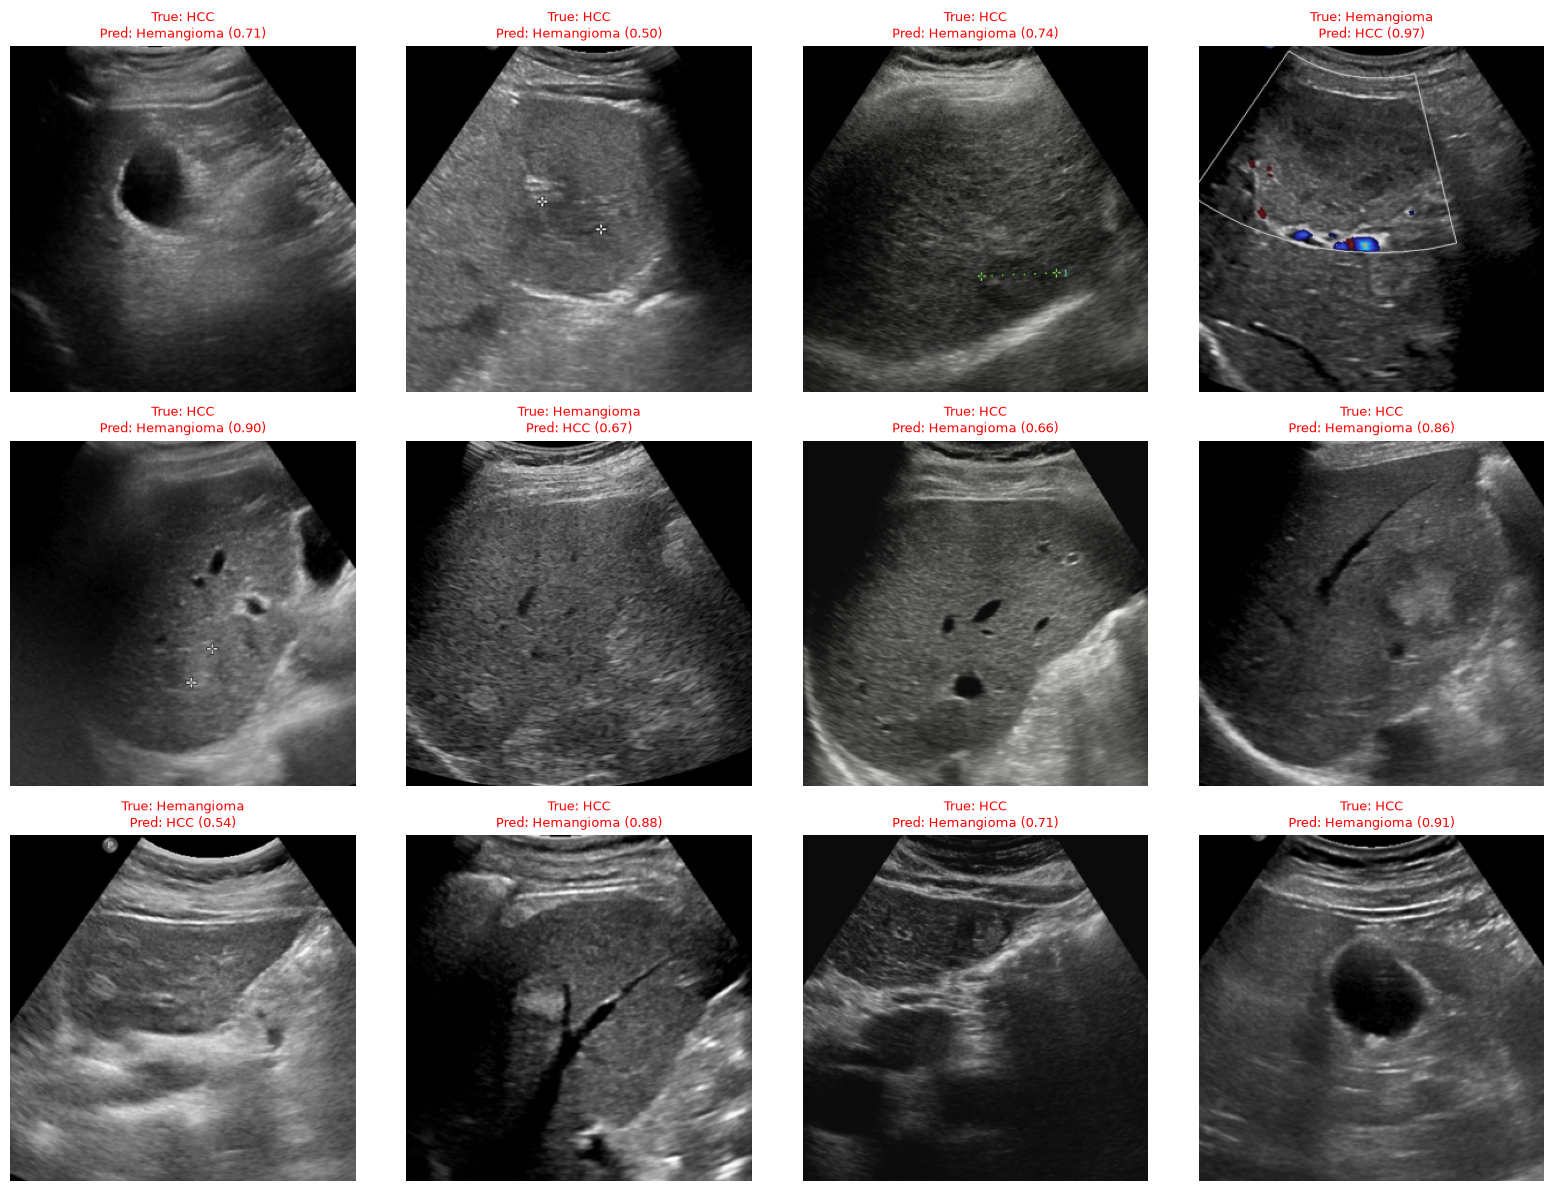

In [49]:
import cv2

def show_misclassified(test_gen, y_true, y_pred, y_pred_probs, class_names, n=12, save_path=None):
    filepaths = test_gen.filepaths  # matches y_true order since shuffle=False
    wrong_idx = np.where(y_true != y_pred)[0]
    print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)}")

    n = min(n, len(wrong_idx))
    if n == 0:
        print("No misclassified images — nothing to show.")
        return

    chosen = np.random.choice(wrong_idx, n, replace=False)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, idx in enumerate(chosen):
        img = cv2.imread(filepaths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        true_cls = class_names[y_true[idx]]
        pred_cls = class_names[y_pred[idx]]
        conf = y_pred_probs[idx][y_pred[idx]]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.2f})", fontsize=9, color="red")
        plt.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

show_misclassified(
    test_gen, results["y_true"], results["y_pred"], results["y_pred_probs"],
    class_names, n=12, save_path=os.path.join(plots_dir, "misclassified_gallery.png")
)

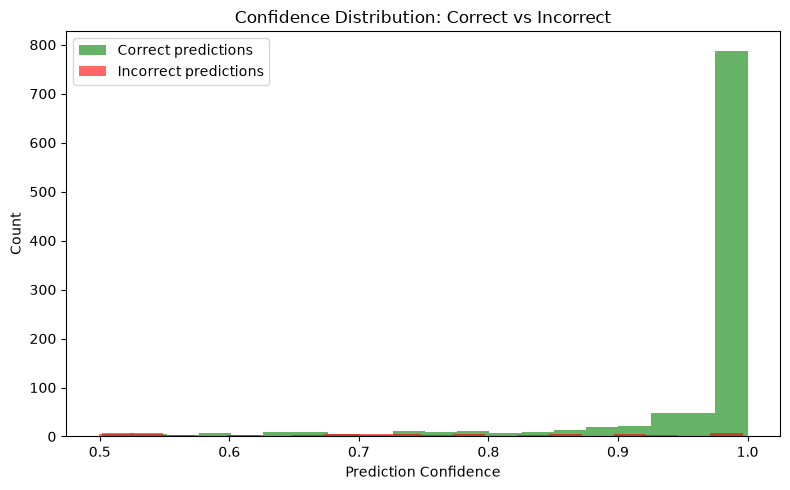

Mean confidence (correct):   0.9570
Mean confidence (incorrect): 0.7489


In [50]:
y_true = results["y_true"]
y_pred = results["y_pred"]
y_pred_probs = results["y_pred_probs"]

confidences = y_pred_probs[np.arange(len(y_pred)), y_pred]  # confidence in the predicted class
correct_mask = y_true == y_pred

plt.figure(figsize=(8, 5))
plt.hist(confidences[correct_mask], bins=20, alpha=0.6, label="Correct predictions", color="green")
plt.hist(confidences[~correct_mask], bins=20, alpha=0.6, label="Incorrect predictions", color="red")
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "confidence_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean confidence (correct):   {confidences[correct_mask].mean():.4f}")
print(f"Mean confidence (incorrect): {confidences[~correct_mask].mean():.4f}")

In [51]:
import tensorflow as tf
import matplotlib.cm as cm

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if len(layer.output_shape) == 4:  # (batch, h, w, channels)
            return layer.name
    raise ValueError("No conv layer found.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(img_path, model, last_conv_layer_name, img_size=IMG_SIZE, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, img_size)
    img_array = preprocess_input(np.expand_dims(img_resized.astype(np.float32), axis=0))

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(overlay); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
    plt.tight_layout()
    plt.show()

last_conv_layer_name = find_last_conv_layer(model)
print("Using conv layer:", last_conv_layer_name)

# Show Grad-CAM for a few misclassified + a few correct examples
filepaths = test_gen.filepaths
sample_idxs = np.random.choice(len(filepaths), 4, replace=False)
for idx in sample_idxs:
    print(f"True: {class_names[y_true[idx]]} | Pred: {class_names[y_pred[idx]]}")
    show_gradcam(filepaths[idx], model, last_conv_layer_name)

AttributeError: 'Dense' object has no attribute 'output_shape'

In [52]:
def tta_consistency_check(model, filepaths, img_size=IMG_SIZE, n_samples=30):
    """
    Checks if predictions stay stable under small flips/rotations.
    Low agreement = fragile model.
    """
    sample_paths = np.random.choice(filepaths, min(n_samples, len(filepaths)), replace=False)
    agreements = []

    for path in sample_paths:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size).astype(np.float32)

        variants = [
            img,
            cv2.flip(img, 1),                                  # horizontal flip
            cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE) if img_size[0]==img_size[1] else img,
        ]
        variants = [preprocess_input(np.expand_dims(v, axis=0)) for v in variants]
        preds = [np.argmax(model.predict(v, verbose=0)[0]) for v in variants]

        agreements.append(len(set(preds)) == 1)  # all variants agree?

    consistency_rate = np.mean(agreements)
    print(f"TTA Consistency Rate: {consistency_rate:.4f} ({int(consistency_rate*len(sample_paths))}/{len(sample_paths)} samples fully agreed)")
    return consistency_rate

tta_consistency_check(model, test_gen.filepaths, n_samples=30)

TTA Consistency Rate: 0.9333 (28/30 samples fully agreed)


np.float64(0.9333333333333333)

In [53]:
filepaths = test_gen.filepaths
extensions = np.array([os.path.splitext(p)[1].lower() for p in filepaths])

print("Accuracy by file format:")
for ext in np.unique(extensions):
    mask = extensions == ext
    if mask.sum() == 0:
        continue
    acc = accuracy_score(y_true[mask], y_pred[mask])
    print(f"  {ext}: {acc:.4f}  (n={mask.sum()})")

Accuracy by file format:
  .png: 0.9290  (n=1126)


In [54]:
import time

sample_batch = next(iter(test_gen))[0]  # one batch of preprocessed images
test_gen.reset()

# Warm-up (first call is always slower due to graph tracing)
_ = model.predict(sample_batch[:1], verbose=0)

n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = model.predict(sample_batch[:1], verbose=0)
elapsed = time.time() - start

print(f"Avg inference time per image: {(elapsed / n_runs) * 1000:.2f} ms")

Avg inference time per image: 147.59 ms


In [55]:
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

approx_size_mb = total_params * 4 / (1024 ** 2)  # assuming float32 (4 bytes/param)

print(f"Total parameters:        {total_params:,}")
print(f"Trainable parameters:    {trainable_params:,}")
print(f"Non-trainable parameters:{non_trainable_params:,}")
print(f"Approx. model size:      {approx_size_mb:.2f} MB")

# If you saved a .h5 file already, check actual file size:
if os.path.exists("best_model.h5"):
    actual_mb = os.path.getsize("best_model.h5") / (1024 ** 2)
    print(f"Actual saved file size:  {actual_mb:.2f} MB")

Total parameters:        2,422,339
Trainable parameters:    1,690,755
Non-trainable parameters:731,584
Approx. model size:      9.24 MB
Actual saved file size:  22.69 MB


In [56]:
import cv2
import numpy as np
import pandas as pd

def detect_caliper_markers(img_path, min_area=3, max_area=60):
    """
    Heuristic detector for small bright caliper-like markers (crosses/pluses)
    on ultrasound images. Not perfect, but good enough to check correlation
    with class — looks for small, very bright, isolated blobs.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0

    # Bright, isolated specks stand out after strong thresholding
    _, thresh = cv2.threshold(img, 240, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    marker_count = 0
    for c in contours:
        area = cv2.contourArea(c)
        if min_area <= area <= max_area:
            marker_count += 1

    return marker_count

# Run across the whole dataset (or test set — adjust path as needed)
records = []
for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        n_markers = detect_caliper_markers(fpath)
        records.append({"class": cls, "filename": fname, "marker_count": n_markers})

df = pd.DataFrame(records)

print("Average detected marker count per class:")
print(df.groupby("class")["marker_count"].mean())

print("\n% of images with at least 1 marker detected, per class:")
print(df.groupby("class")["marker_count"].apply(lambda x: (x > 0).mean() * 100))

Average detected marker count per class:
class
HCC           3.971956
Hemangioma    5.805170
Normal        0.131031
Name: marker_count, dtype: float64

% of images with at least 1 marker detected, per class:
class
HCC           54.575646
Hemangioma    61.970776
Normal         7.994324
Name: marker_count, dtype: float64


In [57]:
import pandas as pd

records = []
for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        img = cv2.imread(fpath)
        if img is None:
            continue
        h, w = img.shape[:2]
        records.append({
            "class": cls,
            "filename": fname,
            "height": h,
            "width": w,
            "aspect_ratio": round(w / h, 3),
            "ext": os.path.splitext(fname)[1].lower()
        })

df_meta = pd.DataFrame(records)

print("Resolution stats by class:")
print(df_meta.groupby("class")[["height", "width", "aspect_ratio"]].describe())

print("\nFile extension distribution by class (%):")
print(pd.crosstab(df_meta["class"], df_meta["ext"], normalize="index") * 100)

Resolution stats by class:
            height                                                            \
             count        mean        std    min    25%    50%    75%    max   
class                                                                          
HCC         2710.0  512.000000   0.000000  512.0  512.0  512.0  512.0  512.0   
Hemangioma  2669.0  578.334208  66.718163  341.0  592.0  592.0  592.0  848.0   
Normal      2114.0  480.000000   0.000000  480.0  480.0  480.0  480.0  480.0   

             width              ...                aspect_ratio            \
             count        mean  ...    75%     max        count      mean   
class                           ...                                         
HCC         2710.0  512.000000  ...  512.0   512.0       2710.0  1.000000   
Hemangioma  2669.0  721.207568  ...  735.0  1051.0       2669.0  1.249411   
Normal      2114.0  640.000000  ...  640.0   640.0       2114.0  1.333000   

                             

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# df_meta already built in the previous cell
df_meta["ext_code"] = LabelEncoder().fit_transform(df_meta["ext"])
X = df_meta[["height", "width", "aspect_ratio", "ext_code"]]
y = df_meta["class"]

X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print(f"Accuracy using ONLY metadata (no pixels): {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds))

Accuracy using ONLY metadata (no pixels): 1.0000
              precision    recall  f1-score   support

         HCC       1.00      1.00      1.00       542
  Hemangioma       1.00      1.00      1.00       534
      Normal       1.00      1.00      1.00       423

    accuracy                           1.00      1499
   macro avg       1.00      1.00      1.00      1499
weighted avg       1.00      1.00      1.00      1499

